## **Polynomial Regression**
### **Import libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
import plotly.express as px
import plotly.graph_objects as go

### **Generate synthetic data (1D)**

In [2]:
np.random.seed(42)
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

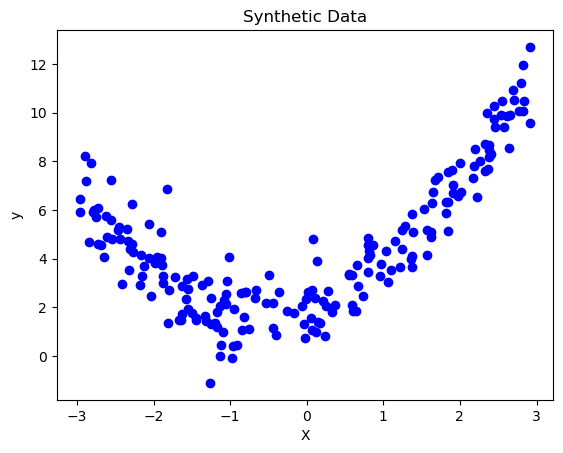

In [3]:

plt.scatter(X, y, color='blue')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data")
plt.show()

### **Train/Test Split**


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)


In [6]:
# Linear Regression (baseline)
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)
print("Linear Regression R²:", r2_score(y_test, y_pred))


Linear Regression R²: 0.3445386715607355


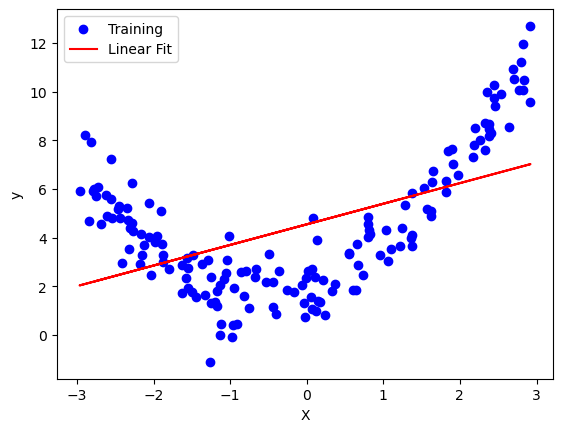

In [7]:

plt.scatter(X_train, y_train, color='blue', label='Training')
plt.plot(X_train, lin_reg.predict(X_train), color='red', label='Linear Fit')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [8]:
# Polynomial Regression (degree=2)
poly_features = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [10]:

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_poly_pred = poly_reg.predict(X_test_poly)
print("Polynomial Regression R²:", r2_score(y_test, y_poly_pred))
print("Coefficients:", poly_reg.coef_)
print("Intercept:", poly_reg.intercept_)

Polynomial Regression R²: 0.841416692467932
Coefficients: [[0.         0.87874406 0.83625305]]
Intercept: [1.96595528]


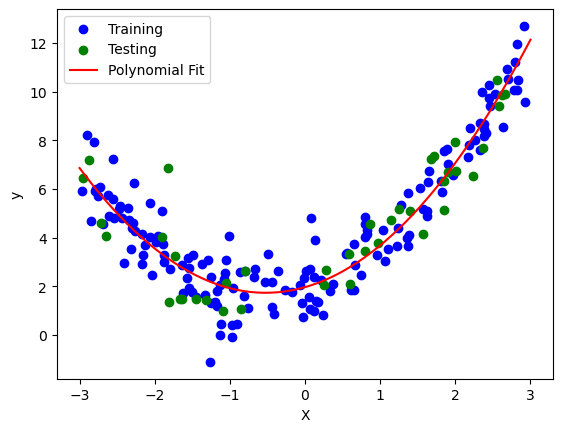

In [11]:
# Plot Polynomial Fit
X_plot = np.linspace(-3, 3, 200).reshape(200, 1)
X_plot_poly = poly_features.transform(X_plot)
y_plot = poly_reg.predict(X_plot_poly)

plt.scatter(X_train, y_train, color='blue', label='Training')
plt.scatter(X_test, y_test, color='green', label='Testing')
plt.plot(X_plot, y_plot, color='red', label='Polynomial Fit')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

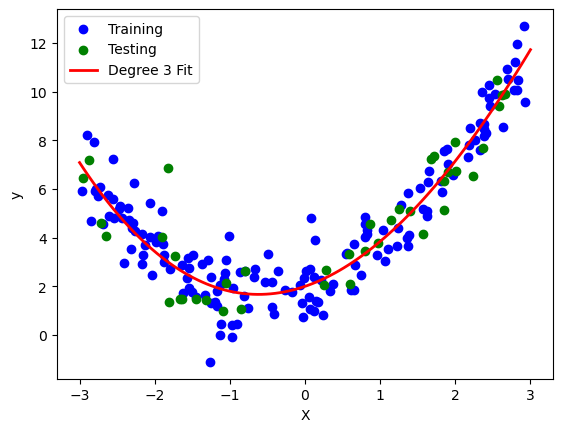

In [19]:
# Polynomial Regression with Pipeline & StandardScaler
def plot_polynomial_regression(X, y, degree=3):
    pipeline = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("lin_reg", LinearRegression())
    ])
    pipeline.fit(X, y)
    
    X_new = np.linspace(-3, 3, 100).reshape(100, 1)
    y_new = pipeline.predict(X_new)
    
    plt.scatter(X_train, y_train, color='blue', label='Training')
    plt.scatter(X_test, y_test, color='green', label='Testing')
    plt.plot(X_new, y_new, color='red', linewidth=2, label=f'Degree {degree} Fit')
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.show()

plot_polynomial_regression(X, y, degree=3)



SGD Regression R²: 0.8403458865191242


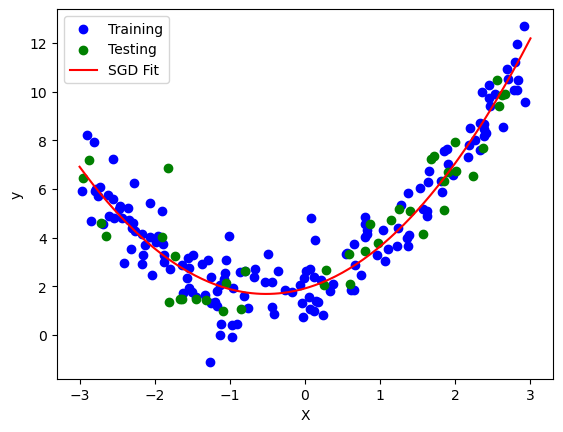

In [20]:
# Gradient Descent Regression
sgd = SGDRegressor(max_iter=1000, tol=1e-3)
sgd.fit(X_train_poly, y_train.ravel())  # Flatten y for SGDRegressor
y_sgd_pred = sgd.predict(X_test_poly)
print("SGD Regression R²:", r2_score(y_test, y_sgd_pred))

plt.scatter(X_train, y_train, color='blue', label='Training')
plt.scatter(X_test, y_test, color='green', label='Testing')
plt.plot(X_plot, sgd.predict(X_plot_poly), color='red', label='SGD Fit')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [21]:
# 3D Polynomial Regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8
z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100, 1)

X_multi = np.hstack([x, y])
poly3d = PolynomialFeatures(degree=2)
X_multi_poly = poly3d.fit_transform(X_multi)

lin_reg_3d = LinearRegression()
lin_reg_3d.fit(X_multi_poly, z)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:

# Grid for surface
x_grid = np.linspace(x.min(), x.max(), 20)
y_grid = np.linspace(y.min(), y.max(), 20)
xg, yg = np.meshgrid(x_grid, y_grid)
grid_points = np.c_[xg.ravel(), yg.ravel()]
grid_poly = poly3d.transform(grid_points)
zg = lin_reg_3d.predict(grid_poly).reshape(xg.shape)

In [23]:
# Plot 3D surface
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.add_trace(go.Surface(x=x_grid, y=y_grid, z=zg, colorscale='Viridis', opacity=0.7))
fig.update_layout(scene=dict(zaxis=dict(range=[0, np.max(zg)])))
fig.show()